# Enron email corpus: exploratory analysis

This notebook works with the extracted Enron maildir in `../enron_mail`. The project notes point to Carnegie Mellon's Enron email release as the source.

The analysis starts with the mail files as they are on disk, then builds cached tables for headers, sampled bodies, engineered fields, and recipient edges. Full body parsing for all 517k files would slow the notebook down without helping the early checks, so text-heavy views use a deterministic sample.

In [1]:
from __future__ import annotations

import hashlib
import os
import re
from collections import Counter
from email import policy
from email.parser import BytesHeaderParser, BytesParser
from email.utils import getaddresses, parsedate_to_datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import networkx as nx
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
from IPython.display import display
from wordcloud import WordCloud

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_theme(context="notebook", style="ticks", palette="colorblind")
px.defaults.template = "plotly_white"

ROOT = Path.cwd().parent
DATA_DIR = ROOT / "enron_mail"
EDA_DIR = ROOT / "eda-2"
CACHE_DIR = EDA_DIR / "cache"
PLOT_DIR = EDA_DIR / "plots"
CACHE_DIR.mkdir(exist_ok=True)
PLOT_DIR.mkdir(exist_ok=True)

HEADER_CACHE = CACHE_DIR / "headers.parquet"
BODY_CACHE = CACHE_DIR / "body_sample.parquet"

assert DATA_DIR.exists(), f"Missing dataset directory: {DATA_DIR}"

## Build the working table

Each file is parsed as one email message. Headers are read for the whole corpus; body text is read later from a stable sample. The cache files in `eda-2/cache/` keep repeated notebook runs fast.

In [2]:
RE_SUBJ_PREFIX = re.compile(r"^\s*(re|fw|fwd|aw|wg)\s*:\s*", re.I)
RE_WS = re.compile(r"\s+")
RE_ATTACHMENT = re.compile(r"<<\s*File\s*:", re.I)
RE_FORWARDED = re.compile(r"[-]+\s*Forwarded by|Original Message|From:\s+.*Sent:", re.I)
INTERNAL_DOMAINS = {"enron.com", "ect.enron.com", "ei.enron.com"}


def iter_message_files(root: Path):
    for dirpath, _dirnames, filenames in os.walk(root):
        for name in filenames:
            yield Path(dirpath) / name


def normalize_subject(value: str | None) -> str:
    text = (value or "").strip()
    previous = None
    while previous != text:
        previous = text
        text = RE_SUBJ_PREFIX.sub("", text)
    return RE_WS.sub(" ", text).strip().lower()


def domain_of(address: str | None) -> str:
    if not address or "@" not in address:
        return ""
    return address.rsplit("@", 1)[-1].lower().strip(" >")


def parse_addresses(value: str | None) -> list[str]:
    if not value:
        return []
    return [addr.lower() for _name, addr in getaddresses([value]) if "@" in addr]


def safe_date(value: str | None):
    if not value:
        return pd.NaT
    try:
        dt = parsedate_to_datetime(value)
        if dt.tzinfo is None:
            return pd.Timestamp(dt).tz_localize("UTC")
        return pd.Timestamp(dt).tz_convert("UTC")
    except Exception:
        return pd.NaT


def stable_sample(path: Path, modulus: int = 20) -> bool:
    digest = hashlib.blake2b(str(path.relative_to(DATA_DIR)).encode(), digest_size=4).hexdigest()
    return int(digest, 16) % modulus == 0


def parse_headers() -> pd.DataFrame:
    parser = BytesHeaderParser(policy=policy.compat32)
    rows = []
    errors = 0

    for idx, path in enumerate(iter_message_files(DATA_DIR), start=1):
        rel = path.relative_to(DATA_DIR)
        parts = rel.parts
        user = parts[0] if parts else ""
        folder = parts[1] if len(parts) > 1 else ""
        try:
            with path.open("rb") as fh:
                msg = parser.parse(fh)
        except Exception:
            errors += 1
            continue

        sender = parse_addresses(msg.get("From"))
        to_addrs = parse_addresses(msg.get("To"))
        cc_addrs = parse_addresses(msg.get("Cc"))
        bcc_addrs = parse_addresses(msg.get("Bcc"))
        recipients = to_addrs + cc_addrs + bcc_addrs
        sender_addr = sender[0] if sender else ""
        sender_domain = domain_of(sender_addr)
        recipient_domains = [domain_of(addr) for addr in recipients]
        external_recipients = sum(1 for d in recipient_domains if d and d not in INTERNAL_DOMAINS)

        rows.append(
            {
                "rel_path": str(rel),
                "user": user,
                "folder": folder,
                "file_name": path.name,
                "file_size": path.stat().st_size,
                "message_id": (msg.get("Message-ID") or "").strip(),
                "date_raw": msg.get("Date") or "",
                "date": safe_date(msg.get("Date")),
                "from_addr": sender_addr,
                "from_domain": sender_domain,
                "to_count": len(to_addrs),
                "cc_count": len(cc_addrs),
                "bcc_count": len(bcc_addrs),
                "recipient_count": len(recipients),
                "external_recipient_count": external_recipients,
                "subject": msg.get("Subject") or "",
                "subject_norm": normalize_subject(msg.get("Subject")),
                "has_in_reply_to": bool(msg.get("In-Reply-To")),
                "has_references": bool(msg.get("References")),
                "content_type": msg.get_content_type(),
                "charset": (msg.get_content_charset() or "<none>").lower(),
                "x_origin": msg.get("X-Origin") or "",
                "x_folder": msg.get("X-Folder") or "",
                "x_filename": msg.get("X-FileName") or "",
            }
        )

        if idx % 100000 == 0:
            print(f"parsed {idx:,} files")

    out = pd.DataFrame(rows)
    out.attrs["header_parse_errors"] = errors
    return out


if HEADER_CACHE.exists():
    headers = pd.read_parquet(HEADER_CACHE)
    print(f"loaded cached headers: {len(headers):,} rows")
else:
    headers = parse_headers()
    headers.to_parquet(HEADER_CACHE, index=False)
    print(f"wrote {HEADER_CACHE.relative_to(ROOT)}")

headers["date"] = pd.to_datetime(headers["date"], utc=True, errors="coerce")
plausible_start = pd.Timestamp("1997-01-01", tz="UTC")
plausible_end = pd.Timestamp("2002-12-31 23:59:59", tz="UTC")
headers["date_plausible"] = headers["date"].between(plausible_start, plausible_end)
headers["month"] = headers["date"].dt.to_period("M").astype("string")
headers["year"] = headers["date"].dt.year
headers["weekday"] = headers["date"].dt.day_name()
headers["hour"] = headers["date"].dt.hour
headers["is_internal_sender"] = headers["from_domain"].isin(INTERNAL_DOMAINS)
headers["has_subject"] = headers["subject_norm"].str.len().gt(0)
headers["folder_lc"] = headers["folder"].str.lower()
headers["folder_group"] = np.select(
    [
        headers["folder_lc"].str.contains("sent", na=False),
        headers["folder_lc"].str.contains("inbox|notes_inbox", na=False),
        headers["folder_lc"].str.contains("deleted", na=False),
        headers["folder_lc"].str.contains("calendar|schedule", na=False),
        headers["folder_lc"].str.contains("discussion", na=False),
    ],
    ["sent", "inbox", "deleted", "calendar", "discussion"],
    default="topic/project",
)

headers.head()

loaded cached headers: 517,401 rows


/tmp/ipykernel_3538848/4015103417.py:128: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  headers["month"] = headers["date"].dt.to_period("M").astype("string")


,rel_path,user,folder,file_name,file_size,message_id,date_raw,date,from_addr,from_domain,...,x_filename,date_plausible,month,year,weekday,hour,is_internal_sender,has_subject,folder_lc,folder_group
0,giron-d/tasks/1.,giron-d,tasks,1.,543,<24643453.1075840560255.JavaMail.evans@thyme>,"Tue, 15 May 2001 07:41:46 -0700 (PDT)",2001-05-15 14:41:46+00:00,outlook-migration-team@enron.com,enron.com,...,darron giron 6-26-02.PST,True,2001-05,2001,Tuesday,14,True,True,tasks,topic/project
1,giron-d/_sent_mail/381.,giron-d,_sent_mail,381.,1229,<5943937.1075854418772.JavaMail.evans@thyme>,"Wed, 20 Dec 2000 09:43:00 -0800 (PST)",2000-12-20 17:43:00+00:00,darron.giron@enron.com,enron.com,...,dgiron.nsf,True,2000-12,2000,Wednesday,17,True,True,_sent_mail,sent
2,giron-d/_sent_mail/315.,giron-d,_sent_mail,315.,989,<25534612.1075854417337.JavaMail.evans@thyme>,"Thu, 18 Jan 2001 05:29:00 -0800 (PST)",2001-01-18 13:29:00+00:00,darron.giron@enron.com,enron.com,...,dgiron.nsf,True,2001-01,2001,Thursday,13,True,True,_sent_mail,sent
3,giron-d/_sent_mail/53.,giron-d,_sent_mail,53.,1668,<24929669.1075854411563.JavaMail.evans@thyme>,"Fri, 20 Apr 2001 05:46:00 -0700 (PDT)",2001-04-20 12:46:00+00:00,darron.giron@enron.com,enron.com,...,dgiron.nsf,True,2001-04,2001,Friday,12,True,True,_sent_mail,sent
4,giron-d/_sent_mail/177.,giron-d,_sent_mail,177.,1818,<28816122.1075854414295.JavaMail.evans@thyme>,"Wed, 28 Feb 2001 08:02:00 -0800 (PST)",2001-02-28 16:02:00+00:00,darron.giron@enron.com,enron.com,...,dgiron.nsf,True,2001-02,2001,Wednesday,16,True,False,_sent_mail,sent


In [3]:
summary = pd.DataFrame(
    {
        "metric": [
            "message files parsed",
            "mailbox owners",
            "folders",
            "unique Message-IDs",
            "duplicate Message-ID files",
            "messages with parseable date",
            "messages inside 1997-2002 date window",
            "raw date range start",
            "raw date range end",
            "1997-2002 range start",
            "1997-2002 range end",
            "median file size, bytes",
        ],
        "value": [
            f"{len(headers):,}",
            f"{headers['user'].nunique():,}",
            f"{headers['folder'].nunique():,}",
            f"{headers.loc[headers['message_id'].ne(''), 'message_id'].nunique():,}",
            f"{headers.loc[headers['message_id'].ne(''), 'message_id'].duplicated(keep=False).sum():,}",
            f"{headers['date'].notna().sum():,}",
            f"{headers['date_plausible'].sum():,}",
            headers["date"].min(),
            headers["date"].max(),
            headers.loc[headers["date_plausible"], "date"].min(),
            headers.loc[headers["date_plausible"], "date"].max(),
            f"{headers['file_size'].median():,.0f}",
        ],
    }
)
display(summary)

,metric,value
0,message files parsed,"517,401"
1,mailbox owners,150
2,folders,"1,427"
3,unique Message-IDs,"517,401"
4,duplicate Message-ID files,0
5,messages with parseable date,"517,401"
6,messages inside 1997-2002 date window,"516,796"
7,raw date range start,1980-01-01 00:00:00+00:00
8,raw date range end,2044-01-04 22:48:58+00:00
9,1997-2002 range start,1997-01-01 17:22:03+00:00


The parsed header table has **517,401** message files from **150** mailbox owners. Every row has a parseable `Date` header, although the raw range runs from **1980-01-01** to **2044-01-04**. Those extremes are timestamp noise. Time plots below use **1997-2002**, which still covers **99.9%** of the files.

`Message-ID` is unique in this release: **0** files repeat an ID. Thread work cannot lean on duplicate IDs here; reply headers and normalized subjects carry more of that signal.

## Mailbox and folder shape

Before reading content, the corpus needs a size check by owner and folder. A few very large mailboxes or generic folders can dominate counts and make company-wide statements look cleaner than the data really is.

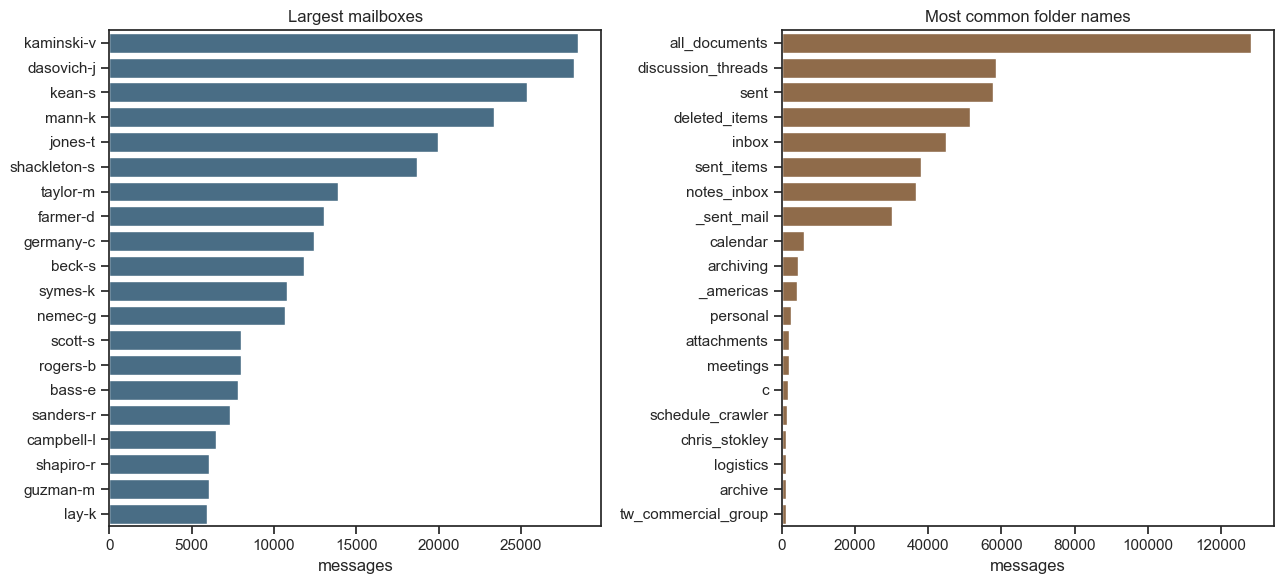

,mailbox_owner,messages
0,kaminski-v,28465
1,dasovich-j,28234
2,kean-s,25351
3,mann-k,23381
4,jones-t,19950
5,shackleton-s,18687
6,taylor-m,13875
7,farmer-d,13032
8,germany-c,12436
9,beck-s,11830


,folder,messages
0,all_documents,128103
1,discussion_threads,58609
2,sent,57653
3,deleted_items,51356
4,inbox,44859
5,sent_items,37921
6,notes_inbox,36665
7,_sent_mail,30109
8,calendar,6133
9,archiving,4477


In [4]:
top_users = headers["user"].value_counts().head(20).rename_axis("mailbox_owner").reset_index(name="messages")
top_folders = headers["folder"].value_counts().head(20).rename_axis("folder").reset_index(name="messages")

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
sns.barplot(data=top_users, y="mailbox_owner", x="messages", ax=axes[0], color="#3f6f8f")
axes[0].set_title("Largest mailboxes")
axes[0].set_xlabel("messages")
axes[0].set_ylabel("")
sns.barplot(data=top_folders, y="folder", x="messages", ax=axes[1], color="#9a6b3f")
axes[1].set_title("Most common folder names")
axes[1].set_xlabel("messages")
axes[1].set_ylabel("")
plt.tight_layout()
plt.savefig(PLOT_DIR / "mailboxes_and_folders.png", bbox_inches="tight")
plt.show()

display(top_users.head(10))
display(top_folders.head(10))

The largest mailbox is **kaminski-v** with **28,465** files. The ten largest mailboxes contain **37.7%** of the corpus. Folder names are even more concentrated: **all_documents** has **128,103** files, and the ten most common folder names cover **88.1%** of all files.

That concentration argues for grouped folder views before comparing senders or time periods.

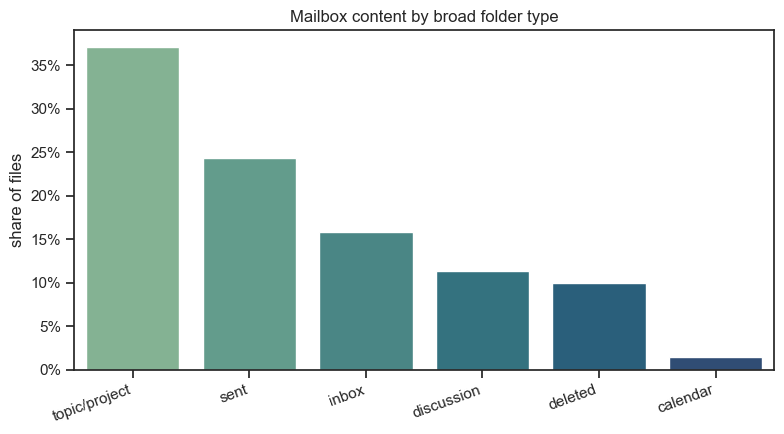

,folder_group,messages,share
0,topic/project,192113,0.371304
1,sent,126058,0.243637
2,inbox,81644,0.157796
3,discussion,58609,0.113276
4,deleted,51415,0.099372
5,calendar,7562,0.014615


In [5]:
folder_mix = (
    headers["folder_group"]
    .value_counts()
    .rename_axis("folder_group")
    .reset_index(name="messages")
)
folder_mix["share"] = folder_mix["messages"] / folder_mix["messages"].sum()

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(data=folder_mix, x="folder_group", y="share", ax=ax, palette="crest", hue="folder_group", legend=False)
ax.set_title("Mailbox content by broad folder type")
ax.set_xlabel("")
ax.set_ylabel("share of files")
ax.yaxis.set_major_formatter(lambda x, _pos: f"{x:.0%}")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(PLOT_DIR / "folder_group_mix.png", bbox_inches="tight")
plt.show()

display(folder_mix)

In [6]:
folder_tree = (
    headers.groupby(["folder_group", "folder"], observed=True)
    .size()
    .rename("messages")
    .reset_index()
    .sort_values("messages", ascending=False)
    .groupby("folder_group", observed=True)
    .head(12)
)
fig = px.treemap(
    folder_tree,
    path=["folder_group", "folder"],
    values="messages",
    color="folder_group",
    title="Folder groups and their largest original folder names",
)
fig.update_traces(textinfo="label+value")
fig.write_html(PLOT_DIR / "folder_treemap.html", include_plotlyjs="cdn")
fig.show()

Grouped folders show why the file-level view matters. Sent folders account for **24.4%** of files, inbox-like folders for **15.8%**, and topic/project folders for **37.1%**. Folder placement is part of the signal, so the analysis keeps message files in their mailbox context instead of collapsing them immediately.

## Dates and volume

The raw `Date` field has a small number of bad values. The charts in this section use messages dated from 1997 through 2002, which preserves the Enron-era traffic and keeps the axis readable.

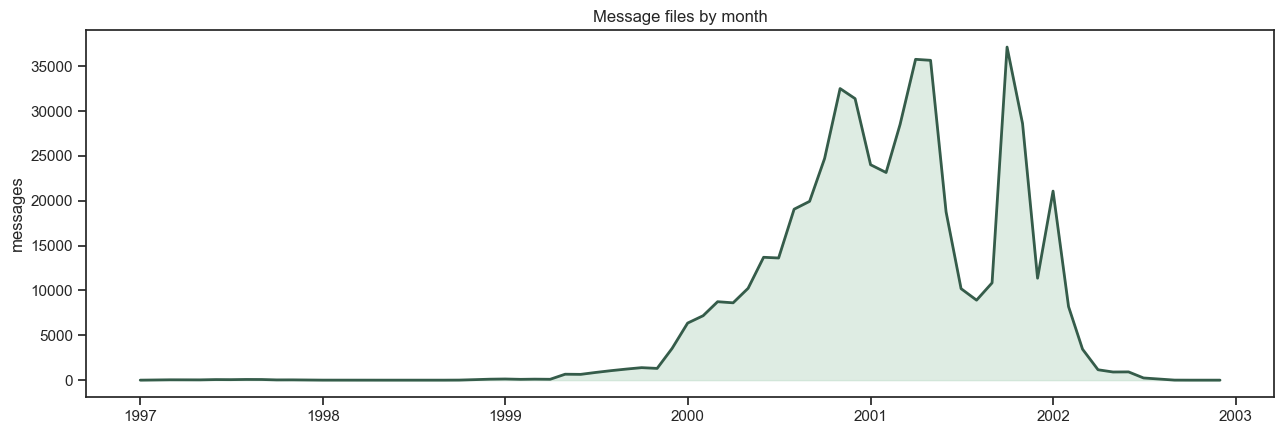

,month,messages
49,2001-10,37139
43,2001-04,35772
44,2001-05,35661
38,2000-11,32513
39,2000-12,31390
50,2001-11,28607
42,2001-03,28513
37,2000-10,24716
40,2001-01,24019
41,2001-02,23153


In [7]:
dated = headers.loc[headers["date_plausible"]].dropna(subset=["date"]).copy()
monthly = dated.groupby("month", observed=True).size().rename("messages").reset_index()
monthly["month_dt"] = pd.to_datetime(monthly["month"].astype(str))

fig, ax = plt.subplots(figsize=(13, 4.5))
sns.lineplot(data=monthly, x="month_dt", y="messages", ax=ax, color="#355c4a", linewidth=2)
ax.fill_between(monthly["month_dt"], monthly["messages"], color="#b6d7c2", alpha=0.45)
ax.set_title("Message files by month")
ax.set_xlabel("")
ax.set_ylabel("messages")
plt.tight_layout()
plt.savefig(PLOT_DIR / "monthly_volume.png", bbox_inches="tight")
plt.show()

display(monthly.sort_values("messages", ascending=False).head(12)[["month", "messages"]])

In [8]:
monthly_group = (
    dated.groupby(["month", "folder_group"], observed=True)
    .size()
    .rename("messages")
    .reset_index()
)
monthly_group["month_dt"] = pd.to_datetime(monthly_group["month"].astype(str))
fig = px.area(
    monthly_group,
    x="month_dt",
    y="messages",
    color="folder_group",
    title="Monthly volume split by broad folder type",
    labels={"month_dt": "", "messages": "messages", "folder_group": "folder group"},
)
fig.write_html(PLOT_DIR / "monthly_folder_area.html", include_plotlyjs="cdn")
fig.show()

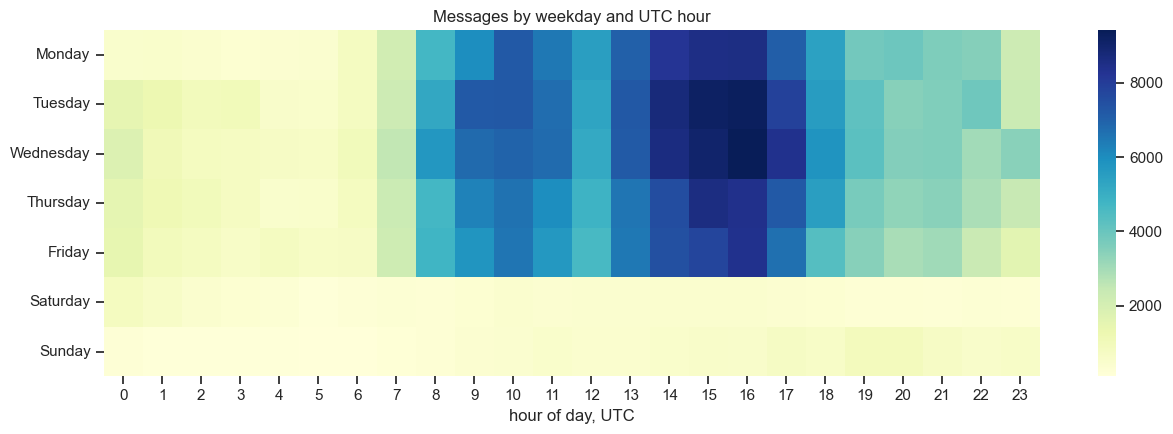

In [9]:
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
heat = (
    dated.pivot_table(index="weekday", columns="hour", values="rel_path", aggfunc="count", fill_value=0)
    .reindex(weekday_order)
)

fig, ax = plt.subplots(figsize=(13, 4.5))
sns.heatmap(heat, cmap="YlGnBu", ax=ax)
ax.set_title("Messages by weekday and UTC hour")
ax.set_xlabel("hour of day, UTC")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(PLOT_DIR / "weekday_hour_heatmap.png", bbox_inches="tight")
plt.show()

The cleaned window peaks in **2001-10** with **37,139** files. Weekend mail is rare at **3.8%**, and the most common UTC hour is **16:00**. Time fields are worth keeping, with the date filter applied before any month- or hour-based features are created.

## Senders, domains, and recipients

Address strings mix normal email addresses, display names, and old internal routing formats. Domain-level cuts are more stable than person-level matching at this stage.

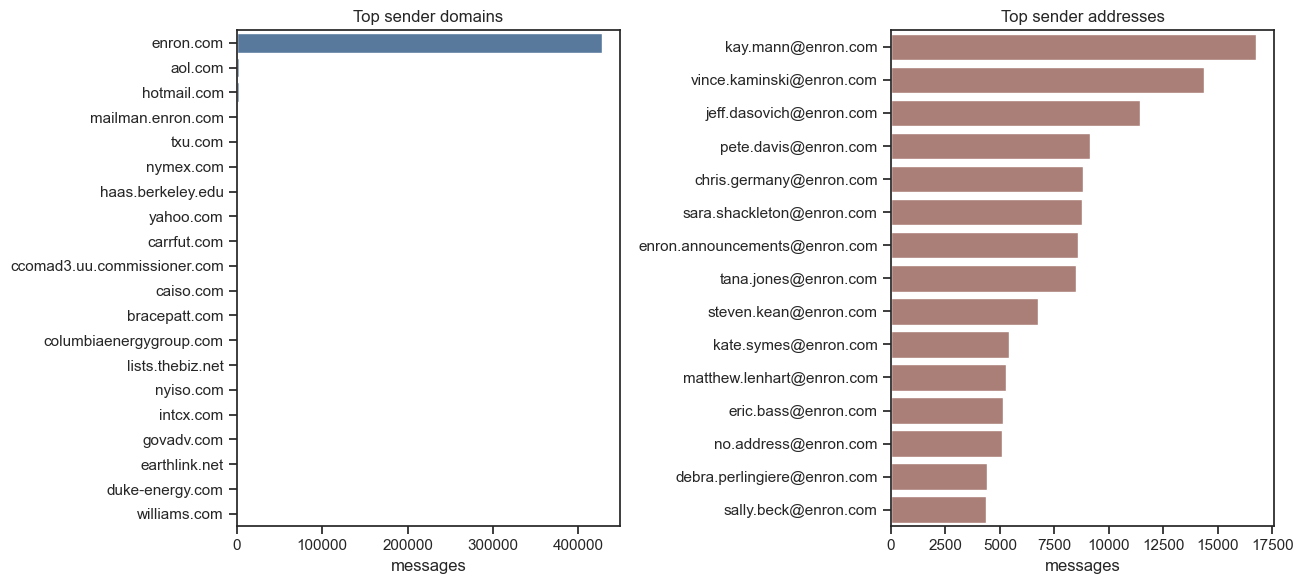

,from_domain,messages
0,enron.com,427783
1,aol.com,2803
2,hotmail.com,2427
3,mailman.enron.com,1775
4,txu.com,1653
5,nymex.com,1438
6,haas.berkeley.edu,1317
7,yahoo.com,1309
8,carrfut.com,1303
9,ccomad3.uu.commissioner.com,877


,from_addr,messages
0,kay.mann@enron.com,16735
1,vince.kaminski@enron.com,14368
2,jeff.dasovich@enron.com,11411
3,pete.davis@enron.com,9149
4,chris.germany@enron.com,8801
5,sara.shackleton@enron.com,8777
6,enron.announcements@enron.com,8587
7,tana.jones@enron.com,8490
8,steven.kean@enron.com,6759
9,kate.symes@enron.com,5438


In [10]:
domain_table = (
    headers.loc[headers["from_domain"].ne(""), "from_domain"]
    .value_counts()
    .head(20)
    .rename_axis("from_domain")
    .reset_index(name="messages")
)
sender_table = (
    headers.loc[headers["from_addr"].ne(""), "from_addr"]
    .value_counts()
    .head(20)
    .rename_axis("from_addr")
    .reset_index(name="messages")
)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
sns.barplot(data=domain_table, y="from_domain", x="messages", ax=axes[0], color="#4c78a8")
axes[0].set_title("Top sender domains")
axes[0].set_xlabel("messages")
axes[0].set_ylabel("")
sns.barplot(data=sender_table.head(15), y="from_addr", x="messages", ax=axes[1], color="#b2796f")
axes[1].set_title("Top sender addresses")
axes[1].set_xlabel("messages")
axes[1].set_ylabel("")
plt.tight_layout()
plt.savefig(PLOT_DIR / "sender_domains_addresses.png", bbox_inches="tight")
plt.show()

display(domain_table.head(10))
display(sender_table.head(10))

In [11]:
top_domain_names = domain_table["from_domain"].head(10).tolist()
domain_folder = (
    headers.loc[headers["from_domain"].isin(top_domain_names)]
    .groupby(["from_domain", "folder_group"], observed=True)
    .size()
    .rename("messages")
    .reset_index()
)
fig = px.sunburst(
    domain_folder,
    path=["from_domain", "folder_group"],
    values="messages",
    title="Top sender domains split by folder group",
)
fig.write_html(PLOT_DIR / "sender_domain_sunburst.html", include_plotlyjs="cdn")
fig.show()

,count,mean,std,min,50%,75%,90%,95%,99%,max
recipient_count,517401.0,8.222568,25.539332,0.0,1.0,5.0,18.0,32.0,113.0,1029.0
to_count,517401.0,6.048757,23.495178,0.0,1.0,2.0,9.0,24.0,107.0,1029.0
cc_count,517401.0,1.086906,4.409988,0.0,0.0,0.0,3.0,6.0,14.0,457.0
external_recipient_count,517401.0,1.161275,9.950698,0.0,0.0,0.0,1.0,3.0,20.0,899.0


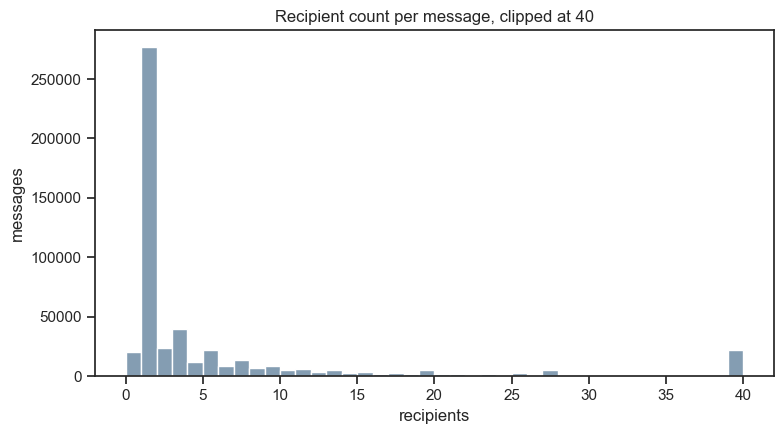

In [12]:
recipient_stats = headers[["recipient_count", "to_count", "cc_count", "external_recipient_count"]].describe(
    percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]
).T
display(recipient_stats)

clipped = headers.assign(recipient_count_clip=headers["recipient_count"].clip(upper=40))
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.histplot(clipped, x="recipient_count_clip", bins=40, ax=ax, color="#5b7c99")
ax.set_title("Recipient count per message, clipped at 40")
ax.set_xlabel("recipients")
ax.set_ylabel("messages")
plt.tight_layout()
plt.savefig(PLOT_DIR / "recipient_count_distribution.png", bbox_inches="tight")
plt.show()

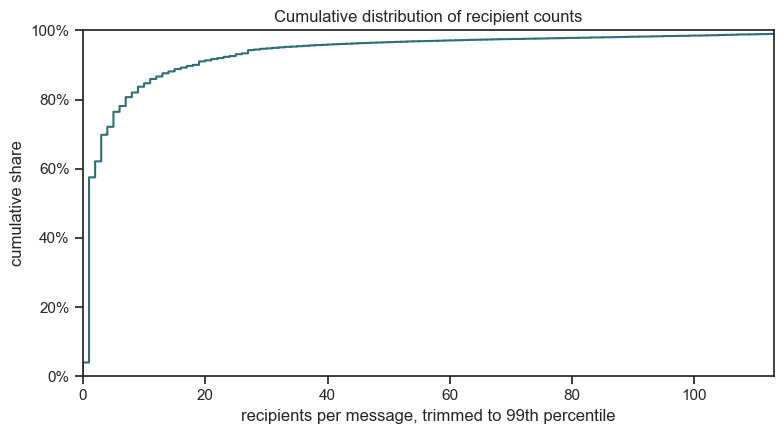

In [13]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.ecdfplot(data=headers, x="recipient_count", ax=ax, color="#2f6f73")
ax.set_xlim(0, headers["recipient_count"].quantile(0.99))
ax.set_title("Cumulative distribution of recipient counts")
ax.set_xlabel("recipients per message, trimmed to 99th percentile")
ax.set_ylabel("cumulative share")
ax.yaxis.set_major_formatter(lambda x, _pos: f"{x:.0%}")
plt.tight_layout()
plt.savefig(PLOT_DIR / "recipient_count_ecdf.png", bbox_inches="tight")
plt.show()

Internal Enron domains supply **82.7%** of sender addresses. At least one external recipient appears in **21.7%** of files. Recipient counts are highly uneven: the median message has **1** recipient, while the 99th percentile reaches **113**. Models need a clipped or log-scaled recipient feature rather than the raw count alone.

## Thread signals

`Message-ID` does not expose duplicates in this parsed copy. Reply headers are almost absent, so repeated normalized subjects become the main cheap proxy for thread-like groups.

,signal,messages,share
0,has In-Reply-To,0,0.000000
1,has References,0,0.000000
2,subject appears in 2+ files,475606,0.919221
3,Message-ID appears in 2+ files,0,0.000000


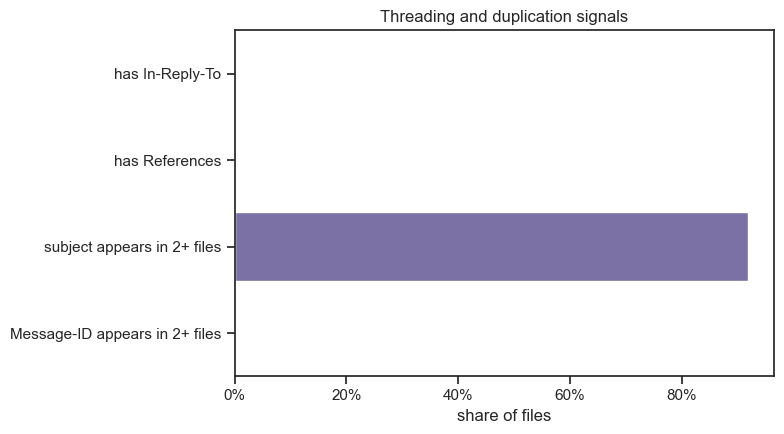

,normalized_subject,files
0,demand ken lay donate proceeds from enron stoc...,1124
1,schedule crawler: hourahead failure,900
2,enron mentions,836
3,schedule crawler: hourahead failure <codesite>,800
4,(no subject),593
5,entouch newsletter,554
6,lunch,537
7,hey,475
8,meeting,453
9,hi,446


In [14]:
thread_summary = pd.DataFrame(
    {
        "signal": [
            "has In-Reply-To",
            "has References",
            "subject appears in 2+ files",
            "Message-ID appears in 2+ files",
        ],
        "messages": [
            int(headers["has_in_reply_to"].sum()),
            int(headers["has_references"].sum()),
            int(headers["subject_norm"].map(headers["subject_norm"].value_counts()).gt(1).sum()),
            int(headers.loc[headers["message_id"].ne(""), "message_id"].map(headers.loc[headers["message_id"].ne(""), "message_id"].value_counts()).gt(1).sum()),
        ],
    }
)
thread_summary["share"] = thread_summary["messages"] / len(headers)
display(thread_summary)

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(data=thread_summary, x="share", y="signal", ax=ax, color="#7768ae")
ax.set_title("Threading and duplication signals")
ax.set_xlabel("share of files")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(lambda x, _pos: f"{x:.0%}")
plt.tight_layout()
plt.savefig(PLOT_DIR / "threading_signals.png", bbox_inches="tight")
plt.show()

top_subjects = (
    headers.loc[headers["subject_norm"].ne(""), "subject_norm"]
    .value_counts()
    .head(15)
    .rename_axis("normalized_subject")
    .reset_index(name="files")
)
display(top_subjects)

In [15]:
subject_user_counts = (
    headers.loc[headers["subject_norm"].isin(top_subjects["normalized_subject"])]
    .groupby("subject_norm", observed=True)["user"]
    .nunique()
    .rename("mailbox_owners")
    .reset_index()
)
subject_plot = top_subjects.merge(
    subject_user_counts,
    left_on="normalized_subject",
    right_on="subject_norm",
    how="left",
)
fig = px.scatter(
    subject_plot,
    x="files",
    y="mailbox_owners",
    size="files",
    hover_name="normalized_subject",
    title="Repeated subjects by file count and mailbox spread",
    labels={"files": "files with subject", "mailbox_owners": "mailbox owners"},
)
fig.write_html(PLOT_DIR / "subject_spread_bubble.html", include_plotlyjs="cdn")
fig.show()

`In-Reply-To` and `References` are both effectively absent. Normalized subjects repeat heavily: **91.9%** of files share a subject with at least one other file. The most repeated subject is **"demand ken lay donate proceeds from enron stock sales"** with **1,124** files.

Subject matching is only a proxy. It can group newsletters, campaigns, and unrelated replies with the same title, so it needs later checks against sender, date, and mailbox spread.

## Body sample

The body sample is used for content checks that do not require reading every message body. It captures message length, forwarded blocks, attachment placeholders, and frequent cleaned tokens.

In [16]:
STOPWORDS = {
    "the", "and", "you", "for", "that", "this", "with", "from", "have", "are", "not",
    "will", "enron", "com", "ect", "hou", "corp", "subject", "cc", "pm", "am",
    "http", "www", "message", "sent", "original", "thanks", "please", "would", "can",
    "all", "has", "was", "but", "they", "his", "her", "she", "him", "its",
    "email", "mail", "attached", "file", "let", "know", "need", "one", "may", "new",
}


def extract_text(msg) -> str:
    chunks = []
    if msg.is_multipart():
        parts = msg.walk()
    else:
        parts = [msg]

    for part in parts:
        content_type = part.get_content_type()
        if content_type != "text/plain":
            continue
        payload = part.get_payload(decode=True)
        if payload is None:
            raw = part.get_payload()
            if isinstance(raw, str):
                chunks.append(raw)
            continue
        charset = part.get_content_charset() or "utf-8"
        try:
            chunks.append(payload.decode(charset, errors="replace"))
        except LookupError:
            chunks.append(payload.decode("latin-1", errors="replace"))
    return "\n".join(chunks)


def parse_body_sample(max_rows: int = 30000) -> pd.DataFrame:
    parser = BytesParser(policy=policy.compat32)
    rows = []
    for path in iter_message_files(DATA_DIR):
        if not stable_sample(path):
            continue
        rel = path.relative_to(DATA_DIR)
        try:
            with path.open("rb") as fh:
                msg = parser.parse(fh)
            text = extract_text(msg)
        except Exception:
            continue

        words = re.findall(r"[A-Za-z][A-Za-z']{2,}", text.lower())
        clean_words = [w for w in words if w not in STOPWORDS and not w.endswith("enron")]
        rows.append(
            {
                "rel_path": str(rel),
                "body_chars": len(text),
                "body_words": len(words),
                "clean_words": " ".join(clean_words[:250]),
                "has_attachment_marker": bool(RE_ATTACHMENT.search(text)),
                "has_forward_marker": bool(RE_FORWARDED.search(text)),
                "question_marks": text.count("?"),
                "exclamation_marks": text.count("!"),
            }
        )
        if len(rows) >= max_rows:
            break
    return pd.DataFrame(rows)


if BODY_CACHE.exists():
    body_sample = pd.read_parquet(BODY_CACHE)
    print(f"loaded cached body sample: {len(body_sample):,} rows")
else:
    body_sample = parse_body_sample()
    body_sample.to_parquet(BODY_CACHE, index=False)
    print(f"wrote {BODY_CACHE.relative_to(ROOT)}")

body_sample.head()

loaded cached body sample: 25,628 rows


,rel_path,body_chars,body_words,clean_words,has_attachment_marker,has_forward_marker,question_marks,exclamation_marks
0,giron-d/_sent_mail/381.,628,74,read forwarded darron giron jeffrey gossett ka...,False,True,0,0
1,giron-d/_sent_mail/326.,1948,237,could read request get back mark info asap for...,False,True,2,0
2,giron-d/_sent_mail/274.,302,21,sorry wrong address forwarded darron giron nor...,False,True,0,0
3,giron-d/_sent_mail/267.,1275,173,forwarded darron giron veronica espinoza larry...,False,True,0,0
4,giron-d/_sent_mail/477.,1746,220,addition expert clauses which ones changed whe...,False,True,1,0


,count,mean,std,min,50%,75%,90%,95%,99%,max
body_chars,25628.0,1788.523958,4997.584662,1.0,765.0,1750.0,3649.0,5869.3,15936.37,197854.0
body_words,25628.0,211.328586,591.477183,0.0,91.0,210.0,441.0,697.0,1868.03,24121.0
question_marks,25628.0,3.135048,58.090104,0.0,0.0,1.0,3.0,6.0,29.00,5693.0
exclamation_marks,25628.0,0.795770,5.829811,0.0,0.0,0.0,2.0,3.0,12.00,279.0


,marker,sample_messages,share_of_sample
0,attachment placeholder,426,0.016622
1,forwarded/original marker,8474,0.330654


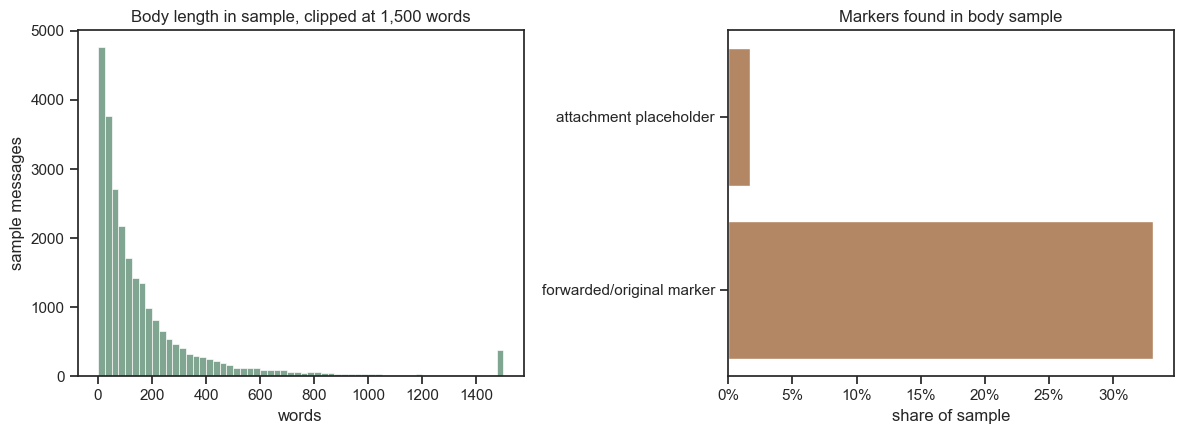

In [17]:
body_summary = body_sample[["body_chars", "body_words", "question_marks", "exclamation_marks"]].describe(
    percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]
).T
marker_summary = pd.DataFrame(
    {
        "marker": ["attachment placeholder", "forwarded/original marker"],
        "sample_messages": [
            int(body_sample["has_attachment_marker"].sum()),
            int(body_sample["has_forward_marker"].sum()),
        ],
    }
)
marker_summary["share_of_sample"] = marker_summary["sample_messages"] / len(body_sample)

display(body_summary)
display(marker_summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(body_sample.assign(body_words_clip=body_sample["body_words"].clip(upper=1500)), x="body_words_clip", bins=60, ax=axes[0], color="#56876d")
axes[0].set_title("Body length in sample, clipped at 1,500 words")
axes[0].set_xlabel("words")
axes[0].set_ylabel("sample messages")
sns.barplot(data=marker_summary, x="share_of_sample", y="marker", ax=axes[1], color="#c08457")
axes[1].set_title("Markers found in body sample")
axes[1].set_xlabel("share of sample")
axes[1].set_ylabel("")
axes[1].xaxis.set_major_formatter(lambda x, _pos: f"{x:.0%}")
plt.tight_layout()
plt.savefig(PLOT_DIR / "body_sample_summary.png", bbox_inches="tight")
plt.show()

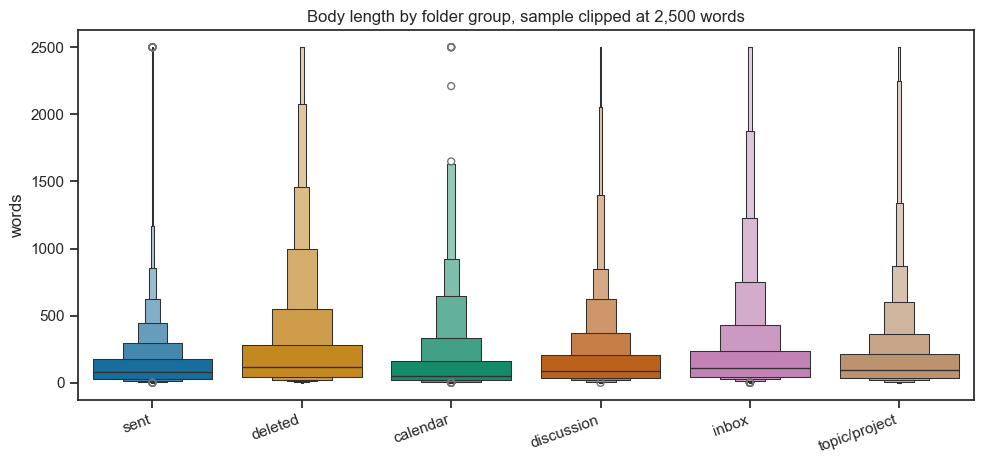

In [18]:
body_enriched = body_sample.merge(
    headers[["rel_path", "folder_group", "recipient_count", "date_plausible"]],
    on="rel_path",
    how="left",
)
fig, ax = plt.subplots(figsize=(10, 4.8))
sns.boxenplot(
    data=body_enriched.assign(body_words_clip=body_enriched["body_words"].clip(upper=2500)),
    x="folder_group",
    y="body_words_clip",
    ax=ax,
    palette="colorblind",
    hue="folder_group",
    legend=False,
)
ax.set_title("Body length by folder group, sample clipped at 2,500 words")
ax.set_xlabel("")
ax.set_ylabel("words")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(PLOT_DIR / "body_length_boxen_by_folder.png", bbox_inches="tight")
plt.show()

The body sample contains **25,628** messages. The median body has **91** words; the 95th percentile reaches **697** words. Attachment placeholders appear in **1.7%** of sampled messages, and forwarded/original-message markers appear in **33.1%**.

Quoted mail and attachment markers are common enough to clean before topic modeling or classification.

,word,count
0,any,11560
1,time,7415
2,energy,7102
3,ees,6857
4,forwarded,6786
5,about,6441
6,out,6298
7,get,6247
8,information,6102
9,gas,6075


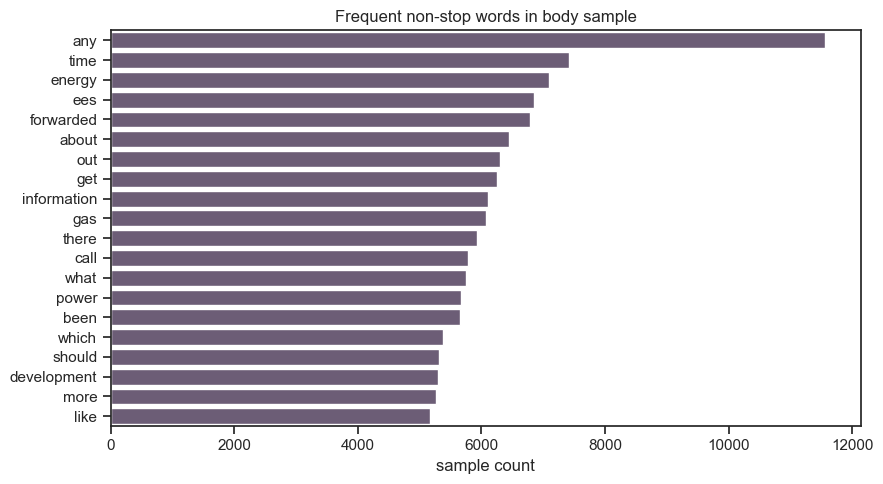

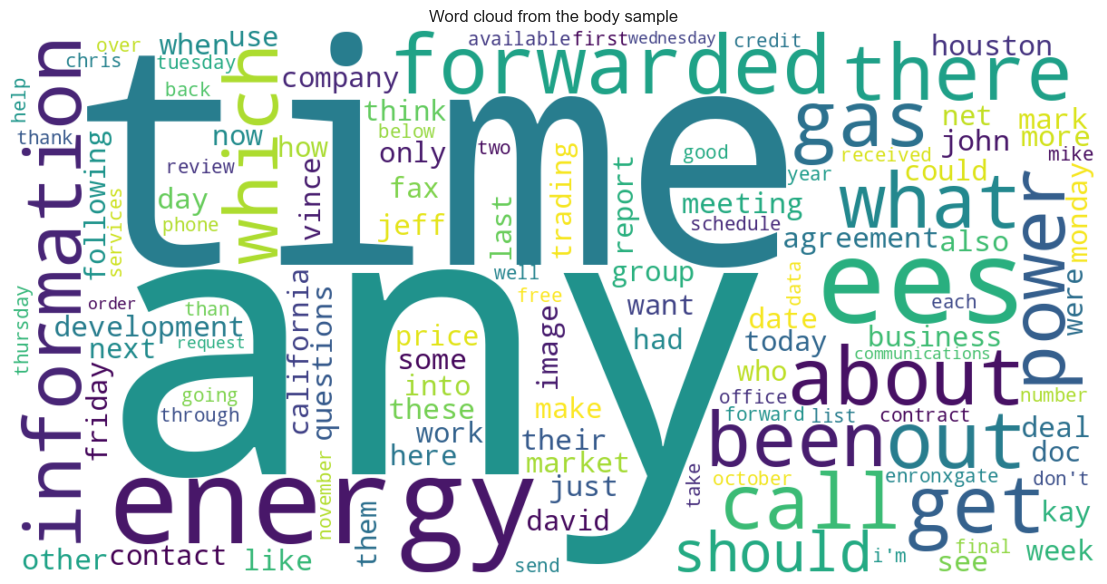

In [19]:
all_words = " ".join(body_sample["clean_words"].dropna())
word_counts = Counter(all_words.split())
top_words = pd.DataFrame(word_counts.most_common(30), columns=["word", "count"])
display(top_words.head(20))

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=top_words.head(20), x="count", y="word", ax=ax, color="#6d597a")
ax.set_title("Frequent non-stop words in body sample")
ax.set_xlabel("sample count")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(PLOT_DIR / "top_body_words.png", bbox_inches="tight")
plt.show()

cloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    colormap="viridis",
    max_words=120,
    random_state=7,
).generate_from_frequencies(word_counts)
fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(cloud, interpolation="bilinear")
ax.axis("off")
ax.set_title("Word cloud from the body sample")
plt.tight_layout()
plt.savefig(PLOT_DIR / "body_wordcloud.png", bbox_inches="tight")
plt.show()

The top cleaned token is **"any"**, which shows that the quick stop-word list is still too thin. The vocabulary plot still works as a rough audit, but a content model needs a custom Enron stop-word list and a pass that separates newly written text from quoted material.

## Engineered header fields

The header table is expanded with fields that can be reused later: subject length, reply/forward prefixes, money and scheduling terms in subjects, file-size scale, path depth, weekend flag, business-hour flag, recipient skew, and date-outlier markers.

In [20]:
RICH_CACHE = CACHE_DIR / "rich_header_features.parquet"

if RICH_CACHE.exists():
    rich = pd.read_parquet(RICH_CACHE)
    print(f"loaded cached rich features: {len(rich):,} rows")
else:
    rich = headers[[
        "rel_path", "user", "folder", "folder_group", "file_size", "date", "date_plausible",
        "from_domain", "from_addr", "recipient_count", "to_count", "cc_count", "bcc_count",
        "external_recipient_count", "subject", "subject_norm", "has_subject", "has_in_reply_to",
        "has_references", "content_type", "charset", "x_origin", "x_filename",
    ]].copy()

    subject_filled = rich["subject"].fillna("")
    rich["subject_chars"] = subject_filled.str.len()
    rich["subject_words"] = subject_filled.str.findall(r"[A-Za-z0-9_]+", flags=re.I).str.len()
    rich["subject_prefix_count"] = subject_filled.str.findall(r"\b(?:re|fw|fwd|aw|wg)\s*:", flags=re.I).str.len()
    rich["subject_has_question"] = subject_filled.str.contains(r"\?", regex=True)
    rich["subject_has_money"] = subject_filled.str.contains(r"\$|price|deal|trade|invoice|payment", case=False, regex=True)
    rich["subject_has_schedule"] = subject_filled.str.contains(r"schedule|meeting|call|calendar|appointment", case=False, regex=True)
    rich["subject_empty"] = rich["subject_norm"].fillna("").eq("")

    rich["file_size_kb"] = rich["file_size"] / 1024
    rich["file_size_log"] = np.log1p(rich["file_size"])
    rich["path_depth"] = rich["rel_path"].str.count("/") + 1
    rich["has_external_recipient"] = rich["external_recipient_count"].gt(0)
    rich["is_internal_sender"] = rich["from_domain"].isin(INTERNAL_DOMAINS)
    rich["recipient_count_log"] = np.log1p(rich["recipient_count"])
    rich["is_mass_message"] = rich["recipient_count"].ge(rich["recipient_count"].quantile(0.99))
    rich["is_weekend"] = rich["date"].dt.dayofweek.ge(5)
    rich["business_hours_utc"] = rich["date"].dt.hour.between(13, 23)
    rich["year_month"] = rich["date"].dt.to_period("M").astype("string")
    rich["day"] = rich["date"].dt.date.astype("string")
    rich["date_outlier"] = ~rich["date_plausible"]

    rich.to_parquet(RICH_CACHE, index=False)
    print(f"wrote {RICH_CACHE.relative_to(ROOT)}")

feature_summary = pd.DataFrame({
    "feature": [
        "subject_empty", "subject_has_money", "subject_has_schedule", "has_external_recipient",
        "is_mass_message", "is_weekend", "business_hours_utc", "date_outlier",
    ],
    "share": [
        rich["subject_empty"].mean(), rich["subject_has_money"].mean(), rich["subject_has_schedule"].mean(),
        rich["has_external_recipient"].mean(), rich["is_mass_message"].mean(), rich["is_weekend"].mean(),
        rich["business_hours_utc"].mean(), rich["date_outlier"].mean(),
    ],
})

numeric_feature_stats = rich[[
    "file_size_kb", "subject_chars", "subject_words", "recipient_count", "external_recipient_count", "path_depth"
]].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]).T

display(feature_summary)
display(numeric_feature_stats)

loaded cached rich features: 517,401 rows


,feature,share
0,subject_empty,0.064236
1,subject_has_money,0.040655
2,subject_has_schedule,0.060220
3,has_external_recipient,0.217431
4,is_mass_message,0.010197
5,is_weekend,0.037845
6,business_hours_utc,0.616097
7,date_outlier,0.001169


,count,mean,std,min,50%,75%,90%,95%,99%,max
file_size_kb,517401.0,2.682397,8.221305,0.388672,1.511719,2.655273,5.007812,7.696289,18.826172,1964.801758
subject_chars,517401.0,28.398683,19.721251,0.000000,25.000000,39.000000,53.000000,63.000000,93.000000,258.000000
subject_words,517401.0,4.687774,3.193049,0.000000,4.000000,6.000000,9.000000,11.000000,15.000000,50.000000
recipient_count,517401.0,8.222568,25.539332,0.000000,1.000000,5.000000,18.000000,32.000000,113.000000,1029.000000
external_recipient_count,517401.0,1.161275,9.950698,0.000000,0.000000,0.000000,1.000000,3.000000,20.000000,899.000000
path_depth,517401.0,3.060325,0.288154,2.000000,3.000000,3.000000,3.000000,4.000000,4.000000,7.000000


The engineered table shows the parts of the corpus that need special handling. Recipient count and file size are long-tailed. Subject flags give quick slices for deal-like mail, scheduling mail, and blank-subject mail, but they are heuristics, not labels.

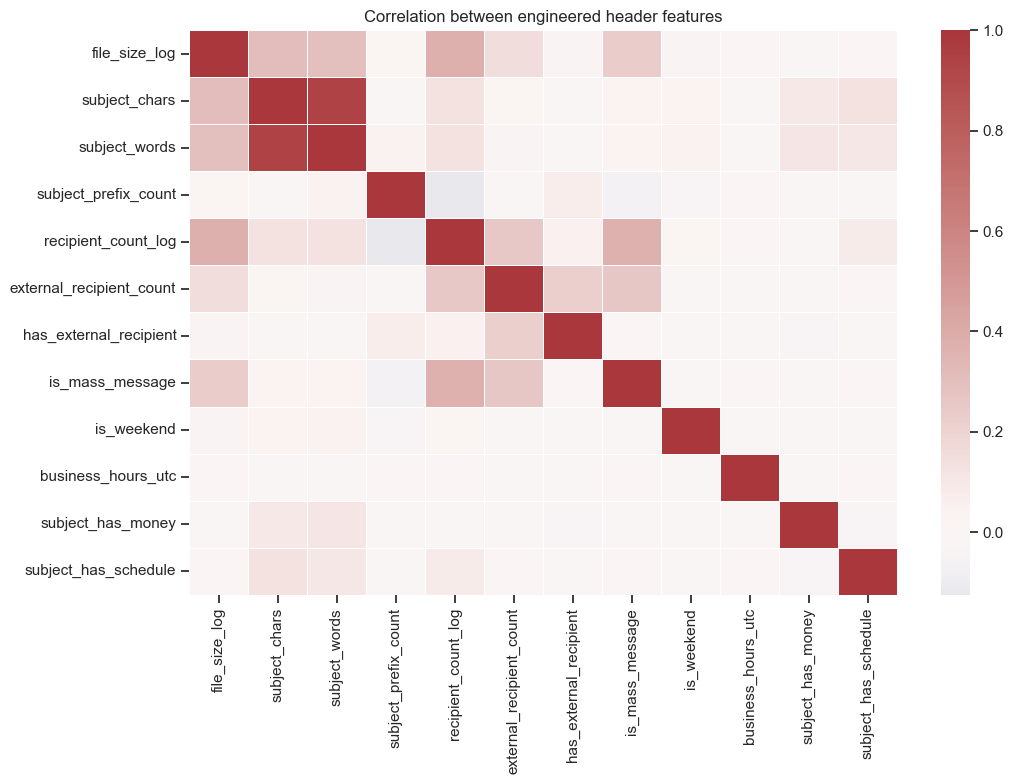

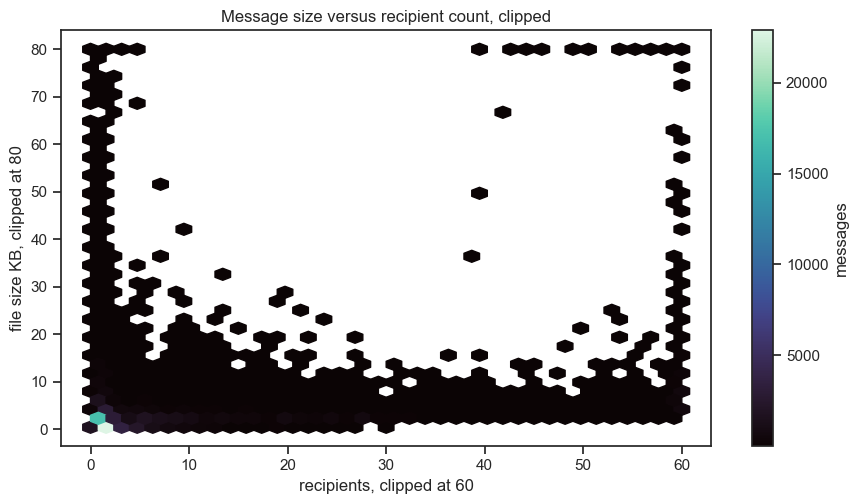

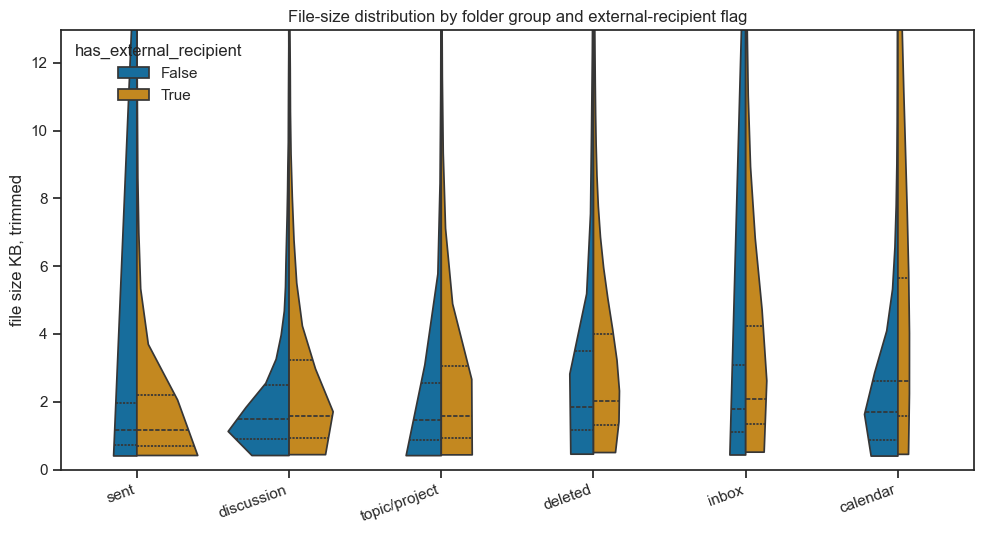

In [21]:
corr_cols = [
    "file_size_log", "subject_chars", "subject_words", "subject_prefix_count", "recipient_count_log",
    "external_recipient_count", "has_external_recipient", "is_mass_message", "is_weekend", "business_hours_utc",
    "subject_has_money", "subject_has_schedule",
]
feature_corr = rich[corr_cols].astype(float).corr()

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(feature_corr, cmap="vlag", center=0, linewidths=0.4, ax=ax)
ax.set_title("Correlation between engineered header features")
plt.tight_layout()
plt.savefig(PLOT_DIR / "engineered_feature_correlation.png", bbox_inches="tight")
plt.show()

plot_sample = rich.loc[rich["date_plausible"]].sample(n=min(80000, rich["date_plausible"].sum()), random_state=7)
fig, ax = plt.subplots(figsize=(9, 5.2))
hb = ax.hexbin(
    plot_sample["recipient_count"].clip(upper=60),
    plot_sample["file_size_kb"].clip(upper=80),
    gridsize=38,
    cmap="mako",
    mincnt=1,
)
fig.colorbar(hb, ax=ax, label="messages")
ax.set_title("Message size versus recipient count, clipped")
ax.set_xlabel("recipients, clipped at 60")
ax.set_ylabel("file size KB, clipped at 80")
plt.tight_layout()
plt.savefig(PLOT_DIR / "size_vs_recipients_hexbin.png", bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(10, 5.5))
sns.violinplot(
    data=plot_sample,
    x="folder_group",
    y="file_size_kb",
    hue="has_external_recipient",
    split=True,
    inner="quart",
    cut=0,
    ax=ax,
)
ax.set_ylim(0, plot_sample["file_size_kb"].quantile(0.98))
ax.set_title("File-size distribution by folder group and external-recipient flag")
ax.set_xlabel("")
ax.set_ylabel("file size KB, trimmed")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(PLOT_DIR / "file_size_violin_external.png", bbox_inches="tight")
plt.show()

In [22]:
feature_mix = (
    rich.assign(
        external=np.where(rich["has_external_recipient"], "external recipient", "internal/no recipient"),
        mass=np.where(rich["is_mass_message"], "mass message", "ordinary"),
        weekend=np.where(rich["is_weekend"], "weekend", "weekday"),
    )
    .sample(n=min(6000, len(rich)), random_state=11)
)

fig = px.parallel_categories(
    feature_mix,
    dimensions=["folder_group", "external", "mass", "weekend"],
    color=feature_mix["recipient_count"].clip(upper=20),
    color_continuous_scale="Tealrose",
    title="Sampled feature paths: folder group, external recipients, mass flag, weekend flag",
)
fig.write_html(PLOT_DIR / "feature_parallel_categories.html", include_plotlyjs="cdn")
fig.show()

subject_flag_mix = (
    rich.groupby("folder_group", observed=True)[["subject_has_money", "subject_has_schedule", "subject_empty"]]
    .mean()
    .reset_index()
    .melt(id_vars="folder_group", var_name="subject_feature", value_name="share")
)
fig = px.bar(
    subject_flag_mix,
    x="folder_group",
    y="share",
    color="subject_feature",
    barmode="group",
    title="Subject-derived feature rates by folder group",
    labels={"folder_group": "folder group", "share": "share of messages"},
)
fig.update_yaxes(tickformat=".0%")
fig.write_html(PLOT_DIR / "subject_feature_mix.html", include_plotlyjs="cdn")
fig.show()

The feature plots make the modeling hazards visible. Size and recipient count need log scaling or clipping. External-recipient mail has an uneven folder mix. Subject flags help with rough slicing, but they are too blunt for class labels.

## Recipient edges

Message-level recipient counts hide the actual communication paths. This section parses `To`, `Cc`, and `Bcc` into sender-recipient edges, then compares domains, channels, and repeated address pairs.

In [23]:
EDGE_CACHE = CACHE_DIR / "recipient_edges.parquet"

if EDGE_CACHE.exists():
    recipient_edges = pd.read_parquet(EDGE_CACHE)
    print(f"loaded cached recipient edges: {len(recipient_edges):,} rows")
else:
    parser = BytesHeaderParser(policy=policy.compat32)
    rows = []
    for idx, path in enumerate(iter_message_files(DATA_DIR), start=1):
        rel = str(path.relative_to(DATA_DIR))
        try:
            with path.open("rb") as fh:
                msg = parser.parse(fh)
        except Exception:
            continue

        senders = parse_addresses(msg.get("From"))
        from_addr = senders[0] if senders else ""
        from_domain = domain_of(from_addr)
        for channel, header in (("to", "To"), ("cc", "Cc"), ("bcc", "Bcc")):
            for recipient_addr in parse_addresses(msg.get(header)):
                rows.append({
                    "rel_path": rel,
                    "from_addr": from_addr,
                    "from_domain": from_domain,
                    "recipient_addr": recipient_addr,
                    "recipient_domain": domain_of(recipient_addr),
                    "channel": channel,
                })

        if idx % 100000 == 0:
            print(f"parsed recipients from {idx:,} files")

    recipient_edges = pd.DataFrame(rows)
    recipient_edges = recipient_edges.merge(
        rich[["rel_path", "folder_group", "date_plausible", "year_month", "is_internal_sender"]],
        on="rel_path",
        how="left",
    )
    recipient_edges["is_internal_recipient"] = recipient_edges["recipient_domain"].isin(INTERNAL_DOMAINS)
    recipient_edges["flow_type"] = np.select(
        [
            recipient_edges["is_internal_sender"] & recipient_edges["is_internal_recipient"],
            recipient_edges["is_internal_sender"] & ~recipient_edges["is_internal_recipient"],
            ~recipient_edges["is_internal_sender"] & recipient_edges["is_internal_recipient"],
        ],
        ["internal to internal", "internal to external", "external to internal"],
        default="external to external",
    )
    recipient_edges.to_parquet(EDGE_CACHE, index=False)
    print(f"wrote {EDGE_CACHE.relative_to(ROOT)}")

edge_summary = pd.DataFrame({
    "metric": [
        "recipient edges", "messages with at least one parsed recipient", "sender domains", "recipient domains",
        "sender addresses", "recipient addresses",
    ],
    "value": [
        f"{len(recipient_edges):,}",
        f"{recipient_edges['rel_path'].nunique():,}",
        f"{recipient_edges['from_domain'].nunique():,}",
        f"{recipient_edges['recipient_domain'].nunique():,}",
        f"{recipient_edges['from_addr'].nunique():,}",
        f"{recipient_edges['recipient_addr'].nunique():,}",
    ],
})

display(edge_summary)
display(recipient_edges.head())

loaded cached recipient edges: 4,254,365 rows


,metric,value
0,recipient edges,"4,254,365"
1,messages with at least one parsed recipient,"496,952"
2,sender domains,"5,167"
3,recipient domains,"11,600"
4,sender addresses,"19,818"
5,recipient addresses,"78,371"


,rel_path,from_addr,from_domain,recipient_addr,recipient_domain,channel,folder_group,date_plausible,year_month,is_internal_sender,is_internal_recipient,flow_type
0,giron-d/_sent_mail/381.,darron.giron@enron.com,enron.com,jason.wolfe@enron.com,enron.com,to,sent,True,2000-12,True,True,internal to internal
1,giron-d/_sent_mail/381.,darron.giron@enron.com,enron.com,anne.bike@enron.com,enron.com,to,sent,True,2000-12,True,True,internal to internal
2,giron-d/_sent_mail/381.,darron.giron@enron.com,enron.com,chris.walker@enron.com,enron.com,to,sent,True,2000-12,True,True,internal to internal
3,giron-d/_sent_mail/381.,darron.giron@enron.com,enron.com,carole.frank@enron.com,enron.com,to,sent,True,2000-12,True,True,internal to internal
4,giron-d/_sent_mail/381.,darron.giron@enron.com,enron.com,jennifer.bagwell@enron.com,enron.com,to,sent,True,2000-12,True,True,internal to internal


In [24]:
flow_counts = (
    recipient_edges.groupby(["flow_type", "channel"], observed=True)
    .size()
    .rename("edges")
    .reset_index()
)
fig = px.bar(
    flow_counts,
    x="flow_type",
    y="edges",
    color="channel",
    title="Recipient edges by direction and header channel",
    labels={"flow_type": "flow direction", "edges": "recipient edges"},
)
fig.write_html(PLOT_DIR / "edge_flow_channel_bar.html", include_plotlyjs="cdn")
fig.show()

monthly_flow = (
    recipient_edges.loc[recipient_edges["date_plausible"]]
    .groupby(["year_month", "flow_type"], observed=True)
    .size()
    .rename("edges")
    .reset_index()
)
monthly_flow["month_dt"] = pd.to_datetime(monthly_flow["year_month"].astype(str))
fig = px.line(
    monthly_flow,
    x="month_dt",
    y="edges",
    color="flow_type",
    title="Monthly recipient-edge volume by direction",
    labels={"month_dt": "", "edges": "recipient edges"},
)
fig.write_html(PLOT_DIR / "monthly_edge_flow.html", include_plotlyjs="cdn")
fig.show()

In [25]:
domain_flows = (
    recipient_edges.loc[recipient_edges["from_domain"].ne("") & recipient_edges["recipient_domain"].ne("")]
    .groupby(["from_domain", "recipient_domain"], observed=True)
    .size()
    .rename("edges")
    .reset_index()
    .sort_values("edges", ascending=False)
    .head(35)
)
labels = pd.Index(pd.concat([domain_flows["from_domain"], domain_flows["recipient_domain"]]).unique())
label_pos = {label: i for i, label in enumerate(labels)}
fig = go.Figure(
    data=[
        go.Sankey(
            node={"label": labels.tolist(), "pad": 14, "thickness": 15},
            link={
                "source": domain_flows["from_domain"].map(label_pos),
                "target": domain_flows["recipient_domain"].map(label_pos),
                "value": domain_flows["edges"],
            },
        )
    ]
)
fig.update_layout(title_text="Top sender-domain to recipient-domain flows", font_size=10)
fig.write_html(PLOT_DIR / "domain_flow_sankey.html", include_plotlyjs="cdn")
fig.show()

display(domain_flows.head(15))

,from_domain,recipient_domain,edges
12423,enron.com,enron.com,3461811
18062,govadv.com,enron.com,15095
11413,enron.com,aol.com,13184
18616,haas.berkeley.edu,haas.berkeley.edu,10354
36385,txu.com,enron.com,7223
7351,columbiaenergygroup.com,enron.com,6286
36388,txu.com,txu.com,6018
12964,enron.com,hotmail.com,4603
11673,enron.com,bracepatt.com,4279
9574,duke-energy.com,duke-energy.com,4177


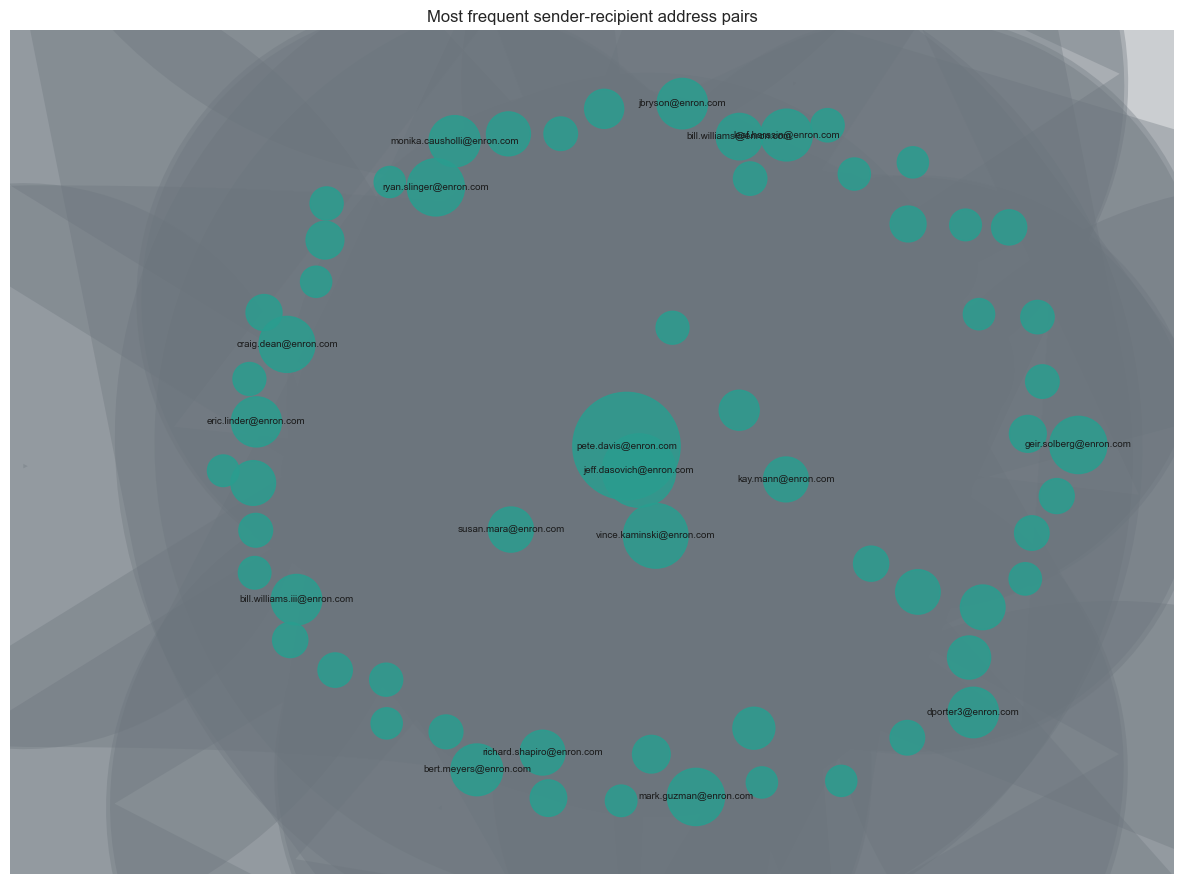

,from_addr,recipient_addr,edges
265926,pete.davis@enron.com,pete.davis@enron.com,27295
265929,pete.davis@enron.com,ryan.slinger@enron.com,18154
265914,pete.davis@enron.com,geir.solberg@enron.com,18142
265922,pete.davis@enron.com,mark.guzman@enron.com,18142
265909,pete.davis@enron.com,craig.dean@enron.com,16570
265921,pete.davis@enron.com,leaf.harasin@enron.com,11930
265904,pete.davis@enron.com,bert.meyers@enron.com,11924
265924,pete.davis@enron.com,monika.causholli@enron.com,11369
265906,pete.davis@enron.com,bill.williams.iii@enron.com,10668
265912,pete.davis@enron.com,dporter3@enron.com,10668


In [26]:
pair_counts = (
    recipient_edges.loc[recipient_edges["from_addr"].ne("") & recipient_edges["recipient_addr"].ne("")]
    .groupby(["from_addr", "recipient_addr"], observed=True)
    .size()
    .rename("edges")
    .reset_index()
    .sort_values("edges", ascending=False)
    .head(60)
)

G = nx.from_pandas_edgelist(
    pair_counts,
    source="from_addr",
    target="recipient_addr",
    edge_attr="edges",
    create_using=nx.DiGraph,
)
weighted_degree = dict(G.degree(weight="edges"))
node_sizes = [80 + 12 * np.sqrt(weighted_degree.get(node, 1)) for node in G.nodes]
edge_widths = [0.4 + 0.04 * G[u][v]["edges"] for u, v in G.edges]
pos = nx.spring_layout(G, seed=7, k=0.8)

fig, ax = plt.subplots(figsize=(12, 9))
nx.draw_networkx_edges(G, pos, ax=ax, width=edge_widths, alpha=0.35, arrows=True, arrowsize=8, edge_color="#6c757d")
nx.draw_networkx_nodes(G, pos, ax=ax, node_size=node_sizes, node_color="#2a9d8f", alpha=0.85)
important_nodes = sorted(weighted_degree, key=weighted_degree.get, reverse=True)[:18]
nx.draw_networkx_labels(G, pos, labels={n: n for n in important_nodes}, font_size=7, ax=ax)
ax.set_title("Most frequent sender-recipient address pairs")
ax.axis("off")
plt.tight_layout()
plt.savefig(PLOT_DIR / "top_address_pair_network.png", bbox_inches="tight")
plt.show()

display(pair_counts.head(20))

The edge table gives a sharper view than recipient counts alone. Internal-to-internal traffic is the largest block, while external-facing edges are a smaller but still visible slice. The address-pair network exposes repeated relationships; aliasing and migrated display names still limit person-level interpretation.

## Data quality and outlier slices

The last checks isolate rows that can distort models: implausible dates, blank subjects, missing senders, zero parsed recipients, very large recipient lists, and very large files.

In [27]:
quality_table = pd.DataFrame({
    "check": [
        "date outside 1997-2002", "blank normalized subject", "missing sender address",
        "zero parsed recipients", "mass-message threshold", "file-size 99th percentile KB",
    ],
    "count_or_value": [
        f"{rich['date_outlier'].sum():,}",
        f"{rich['subject_empty'].sum():,}",
        f"{rich['from_addr'].eq('').sum():,}",
        f"{rich['recipient_count'].eq(0).sum():,}",
        f"{rich['recipient_count'].quantile(0.99):.0f} recipients",
        f"{rich['file_size_kb'].quantile(0.99):.1f} KB",
    ],
    "share": [
        rich['date_outlier'].mean(), rich['subject_empty'].mean(), rich['from_addr'].eq('').mean(),
        rich['recipient_count'].eq(0).mean(), np.nan, np.nan,
    ],
})

date_outliers = rich.loc[rich["date_outlier"], ["rel_path", "date", "user", "folder", "from_addr", "subject"]].sort_values("date")
large_recipient_messages = rich.sort_values("recipient_count", ascending=False)[[
    "rel_path", "date", "folder_group", "from_addr", "recipient_count", "external_recipient_count", "subject",
]].head(15)
large_files = rich.sort_values("file_size", ascending=False)[[
    "rel_path", "date", "folder_group", "from_addr", "file_size_kb", "recipient_count", "subject",
]].head(15)

display(quality_table)
display(date_outliers.head(15))
display(large_recipient_messages)
display(large_files)

,check,count_or_value,share
0,date outside 1997-2002,605,0.001169
1,blank normalized subject,"33,236",0.064236
2,missing sender address,3,0.000006
3,zero parsed recipients,"20,449",0.039523
4,mass-message threshold,113 recipients,NaN
5,file-size 99th percentile KB,18.8 KB,NaN


,rel_path,date,user,folder,from_addr,subject
5870,griffith-j/discussion_threads/226.,1980-01-01 00:00:00+00:00,griffith-j,discussion_threads,john.griffith@enron.com,Don't forget to register!
343849,stclair-c/all_documents/2327.,1980-01-01 00:00:00+00:00,stclair-c,all_documents,carol.clair@enron.com,Re: FW: Mitsui-Enron Contract
340394,whalley-l/all_documents/279.,1980-01-01 00:00:00+00:00,whalley-l,all_documents,greg.whalley@enron.com,Re:
340269,whalley-l/all_documents/362.,1980-01-01 00:00:00+00:00,whalley-l,all_documents,outlook.team@enron.com,3 - URGENT - TO PREVENT LOSS OF INFORMATION
339722,whalley-l/notes_inbox/1.,1980-01-01 00:00:00+00:00,whalley-l,notes_inbox,outlook.team@enron.com,3 - URGENT - TO PREVENT LOSS OF INFORMATION
339322,whalley-l/discussion_threads/257.,1980-01-01 00:00:00+00:00,whalley-l,discussion_threads,greg.whalley@enron.com,Re:
339138,whalley-l/discussion_threads/340.,1980-01-01 00:00:00+00:00,whalley-l,discussion_threads,outlook.team@enron.com,3 - URGENT - TO PREVENT LOSS OF INFORMATION
337255,cash-m/all_documents/617.,1980-01-01 00:00:00+00:00,cash-m,all_documents,michelle.cash@enron.com,Re:
337072,cash-m/all_documents/716.,1980-01-01 00:00:00+00:00,cash-m,all_documents,michelle.cash@enron.com,2001 Law Conference
337034,cash-m/all_documents/626.,1980-01-01 00:00:00+00:00,cash-m,all_documents,michelle.cash@enron.com,Re: Opportunities at ENA


,rel_path,date,folder_group,from_addr,recipient_count,external_recipient_count,subject
104837,saibi-e/inbox/468.,2001-09-24 22:11:51+00:00,inbox,lisa.jones@enron.com,1029,0,Analyst or Associate - Middle Market
130494,rogers-b/enron_news/25.,2001-08-23 18:24:25+00:00,topic/project,kenneth.lay@enron.com,948,0,Associate/Analyst Program
273785,mclaughlin-e/deleted_items/248.,2001-08-23 18:24:25+00:00,deleted,kenneth.lay@enron.com,948,0,Associate/Analyst Program
53410,baughman-d/enron_power/24_hour/12.,2001-08-23 18:24:25+00:00,topic/project,kenneth.lay@enron.com,948,0,Associate/Analyst Program
51796,baughman-d/power/24_hour/188.,2001-08-23 18:24:25+00:00,topic/project,kenneth.lay@enron.com,948,0,Associate/Analyst Program
273122,mclaughlin-e/private_folders/corp_info_announc...,2001-08-23 18:24:25+00:00,topic/project,kenneth.lay@enron.com,948,0,Associate/Analyst Program
474043,buy-r/inbox/714.,2001-08-23 18:24:25+00:00,inbox,kenneth.lay@enron.com,948,0,Associate/Analyst Program
480654,lay-k/sent_items/10.,2001-08-23 18:24:25+00:00,sent,kenneth.lay@enron.com,947,0,Associate/Analyst Program
324228,weldon-c/associate/7.,2001-08-23 18:24:25+00:00,topic/project,kenneth.lay@enron.com,947,0,Associate/Analyst Program
210807,lenhart-m/deleted_items/2.,2001-05-30 23:48:18+00:00,deleted,constance.charles@enron.com,933,0,"MAY 16-30, 2001 TIMESHEETS"


,rel_path,date,folder_group,from_addr,file_size_kb,recipient_count,subject
68565,dorland-c/deleted_items/20.,2002-02-01 17:16:11+00:00,deleted,postmaster@blakes.com,1964.801758,1,Returned Mail: Error During Delivery
439691,guzman-m/discussion_threads/1045.,2001-03-06 19:17:00+00:00,discussion,mailer-daemon@postmaster.enron.com,1657.970703,1,Returned mail: Host unknown (Name server: epec...
441978,guzman-m/all_documents/893.,2001-03-06 19:17:00+00:00,topic/project,mailer-daemon@postmaster.enron.com,1657.964844,1,Returned mail: Host unknown (Name server: epec...
440503,guzman-m/notes_inbox/841.,2001-03-06 19:17:00+00:00,inbox,mailer-daemon@postmaster.enron.com,1657.961914,1,Returned mail: Host unknown (Name server: epec...
454255,forney-j/sent_items/158.,2001-05-24 17:41:00+00:00,sent,no.address@enron.com,1615.308594,1,jforney
451026,presto-k/sent_items/1103.,2001-05-23 03:18:00+00:00,sent,no.address@enron.com,1339.736328,1,kpresto
191459,kean-s/deleted_items/434.,2001-11-25 21:14:38+00:00,deleted,postmaster@bc-corpmail01.bruncorp.com,802.153320,1,Undeliverable message
292285,haedicke-m/all_documents/1364.,2001-06-11 10:35:00+00:00,topic/project,henry.emery@ubspainewebber.com,524.842773,0,
290896,haedicke-m/notes_inbox/13.,2001-06-11 10:35:00+00:00,inbox,henry.emery@ubspainewebber.com,524.839844,0,
298862,martin-t/inbox/98.,2002-01-18 17:52:41+00:00,inbox,sarah.palmer@enron.com,390.762695,1,Enron Mentions -- 01/18/02


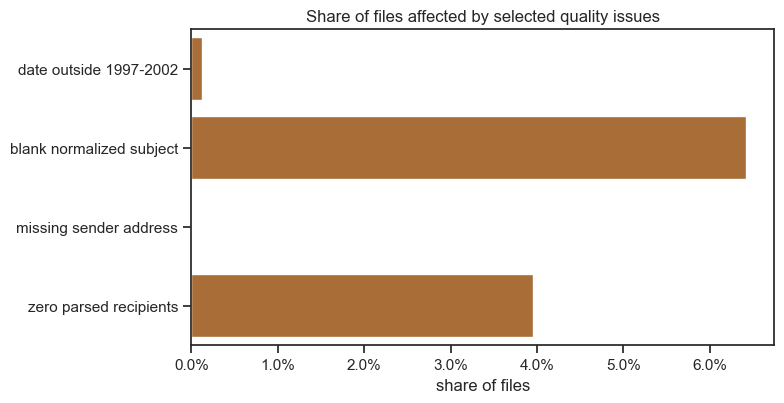

In [28]:
quality_plot = quality_table.dropna(subset=["share"]).copy()
fig, ax = plt.subplots(figsize=(8, 4.2))
sns.barplot(data=quality_plot, x="share", y="check", ax=ax, color="#bc6c25")
ax.set_title("Share of files affected by selected quality issues")
ax.set_xlabel("share of files")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(lambda x, _pos: f"{x:.1%}")
plt.tight_layout()
plt.savefig(PLOT_DIR / "quality_issue_rates.png", bbox_inches="tight")
plt.show()

outlier_mix = rich.assign(
    recipient_bucket=pd.cut(
        rich["recipient_count"],
        bins=[-1, 0, 1, 5, 20, np.inf],
        labels=["0", "1", "2-5", "6-20", "21+"],
    )
)
recipient_bucket_mix = (
    outlier_mix.groupby(["folder_group", "recipient_bucket"], observed=True)
    .size()
    .rename("messages")
    .reset_index()
)
fig = px.bar(
    recipient_bucket_mix,
    x="folder_group",
    y="messages",
    color="recipient_bucket",
    title="Recipient-count buckets by folder group",
    labels={"folder_group": "folder group", "recipient_bucket": "recipients"},
)
fig.write_html(PLOT_DIR / "recipient_bucket_by_folder.html", include_plotlyjs="cdn")
fig.show()

For modeling, start from the richer cached table. Keep explicit flags for quality issues, filter implausible dates for temporal features, and transform long-tailed variables such as recipient count and file size.

## What to carry forward

The notebook now has four analysis tables: headers, engineered header features, sampled body text, and recipient edges. The reusable fields with the least cleanup burden are mailbox owner, folder group, filtered timestamp, sender and recipient domains, recipient-count scale, external-recipient flags, subject-shape flags, body length, repeated normalized subjects, and edge counts.

The main risks are visible in the tables. Dates include outliers, addresses include aliases and migration artifacts, repeated subjects are weak thread evidence, and body text contains forwarded blocks plus attachment placeholders. A modeling pass should start from the cached feature tables rather than the raw mail files.

## Course plan and modeling direction

The near-term course work splits cleanly into two tracks. Descriptive mining can use the current notebook almost as-is: mailbox volume, folder mix, time patterns, sender domains, recipient flows, repeated subjects, body length, and quality checks are already cached and plotted. Predictive mining should start from `eda-2/cache/rich_header_features.parquet`, with `eda-2/cache/recipient_edges.parquet` joined in only when network features are needed.

| Date | Course topic | Work connected to this dataset |
|---|---|---|
| May 13 | Descriptive Mining 2 | Clean feature table, mailbox/folder/time summaries, quality checks |
| May 20 | Descriptive Mining 3 | Sender-domain and recipient-flow views, subject repetition, body-sample vocabulary |
| May 27 | Descriptive Mining 4 | Network-style views from sender-recipient edges, outlier slices |
| Jun 3 | Descriptive Mining 5 | Refine plots for presentation, compare user groups or folder groups |
| Jun 10 | Descriptive Mining 6 | Freeze descriptive story and decide predictive task |
| Jun 17 | Predictive Mining 1 | Build train/test split, baseline model, leakage checks |
| Jun 24 | Predictive Mining 2 | Add feature groups, tune model, inspect errors |
| Jul 1 | Predictive Mining 3 | Final model comparison and interpretation |
| Jul 8 / Jul 15 | Final presentations | Present dataset, EDA, modeling target, model results, limits |

For the shared Colab page, the safest setup is to load the cached parquet files instead of reparsing the raw maildir. The raw corpus is too large for repeated classroom runs. A compact Colab can mount or upload `rich_header_features.parquet`, `body_sample.parquet`, and, if network tasks are used, `recipient_edges.parquet`. The notebook should keep the raw parsing cells in this local version for reproducibility, but the Colab version can start from the cached tables.

The first feature set should stay close to headers: `folder_group`, mailbox owner, sender domain, recipient counts, external-recipient flags, subject length, reply/forward prefix count, subject flags for money and scheduling terms, file-size log, weekend flag, UTC hour, month, and date-quality flags. A second feature set can add body-sample fields such as word count, attachment marker, forwarded marker, and cleaned-token counts. A third feature set can add network aggregates from recipient edges: sender out-degree, recipient in-degree, sender-domain flow counts, share of external recipients, and repeated address-pair counts.

Good prediction targets are targets already visible in headers, not labels invented after reading message content. Three candidates fit the current tables. The most straightforward target is **folder group prediction**: predict `folder_group` from sender, time, subject, size, and recipient features. A second target is **external-recipient prediction**: predict whether a message has at least one external recipient. A third target is **mass-message detection**: predict whether recipient count falls in the top one percent. Folder group prediction is the best first model because it has several classes, enough rows, and a clear link to the descriptive analysis.

The first modeling notebook should use a time-aware split: train on earlier months in the 1997-2002 window and test on later months. A random split would overstate performance because repeated subjects, recurring senders, and mailbox habits leak across rows. Baselines can be simple: majority class, logistic regression, and a tree-based model. Model interpretation should report which feature groups matter, not only accuracy.